<a href="https://colab.research.google.com/github/surenyan/Optimization-Methods/blob/main/Selection_Method/Selection_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sympy as sp
x = sp.symbols('x')
f = 1/4*x**4 +x**2 -8*x + 12
df = sp.diff(f, x)
print("f(x) =", f)
print("f'(x) =", df)
roots = sp.solve(df, x)
print("Roots of derivative:", roots)

f(x) = 0.25*x**4 + x**2 - 8*x + 12
f'(x) = 1.0*x**3 + 2*x - 8
Roots of derivative: [1.67024469696273, -0.835122348481367 - 2.02294043678975*I, -0.835122348481367 + 2.02294043678975*I]


In [2]:
a = 0
b = 2
n = 4
epsilon = 0.5

In [3]:
f_num = sp.lambdify(x, f)
x_vals = []
f_vals = []

for k in range(n+1):
    xk = a + k*((b-a)/n)
    fx = f_num(xk)

    x_vals.append(xk)
    f_vals.append(fx)

    print("k =", k, "xk =", xk, "f(xk) =", fx)

xmin = min(x_vals, key=f_num)
fmin = f_num(xmin)

print("\nxmin=",xmin)
print("f_min=", fmin)


k = 0 xk = 0.0 f(xk) = 12.0
k = 1 xk = 0.5 f(xk) = 8.265625
k = 2 xk = 1.0 f(xk) = 5.25
k = 3 xk = 1.5 f(xk) = 3.515625
k = 4 xk = 2.0 f(xk) = 4.0

xmin= 1.5
f_min= 3.515625


In [4]:
x_star = None
for r in roots:
    if r.is_real and a <= r <= b:
        if x_star is None or f_num(r) < f_num(x_star):
            x_star = r

print("x* =", x_star)

x* = 1.67024469696273


In [5]:
print("|xmin - x*| =", abs(xmin - x_star))

if abs(xmin - x_star) <= epsilon:
    print("Condition satisfied")
else:
    print("Condition not satisfied")

|xmin - x*| = 0.170244696962733
Condition satisfied


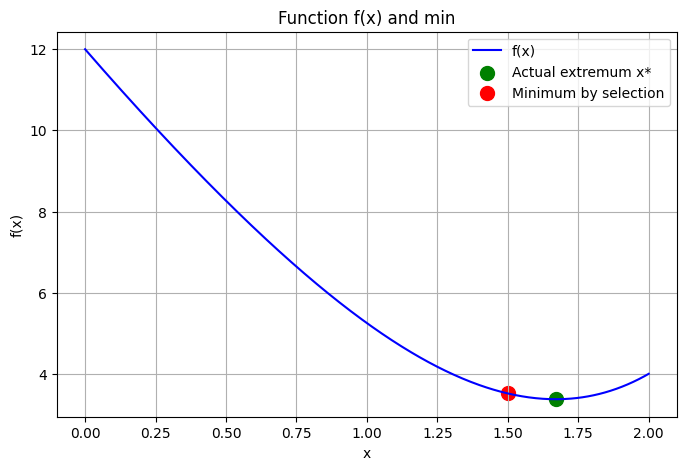

In [8]:
import numpy as np
import matplotlib.pyplot as plt
x_plot = np.linspace(a, b, 400)
y_plot = f_num(x_plot)

plt.figure(figsize=(8,5))
plt.plot(x_plot, y_plot, label='f(x)', color='blue')  # function
plt.scatter(x_star, f_num(x_star), color='green', s=100, label='Actual extremum x*')  # actual extremum
plt.scatter(xmin, fmin, color='red', s=100, label='Minimum by selection')  # selection method

plt.title("Function f(x) and min")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()
